# **02 - Analysis and Visualizations**

## Objectives
* Analyse the cleaned online retail dataset to answer 4 business requirements 
  through visualisations

## Inputs
* data/processed/online_retail_cleaned.csv

## Outputs
* 4 visualisations answering business requirements

## Additional Comments
* Cleaned data produced in notebook 01_load_and_clean_data.ipynb

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os

current_dir = os.getcwd()
current_dir

'/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_1/DA_project_1/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [4]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [5]:
current_dir = os.getcwd()
current_dir

'/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_1/DA_project_1'

In [ ]:
#!pip install -r requirements.txt

# Import necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.pipeline import Pipeline
from feature_engine import transformation as vt

# Section 1 - Load Cleaned Data

In this section, we load the cleaned transaction data from the source CSV file and prepare it as a DataFrame for analysis.

* Input: data/processed/online_retail_cleaned.csv

In [6]:
df = pd.read_csv("data/processed/online_retail_cleaned.csv")
print(df.shape)
df.head()

(524878, 11)


/var/folders/c0/b3t2bq595gxctk3zh1z0tr_h0000gn/T/ipykernel_85403/3639861713.py:1: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/processed/online_retail_cleaned.csv")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010


## Descriptive Statistics

Basic statistical summary of the cleaned dataset.

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID,TotalPrice,Month,Year
count,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,15287.631345,20.275399,7.552237,2010.921904
std,156.280031,36.093028,1482.145530,271.693566,3.508164,0.268323
min,1.000000,0.001000,12346.000000,0.001000,1.000000,2010.000000
25%,1.000000,1.250000,14375.000000,3.900000,5.000000,2011.000000
50%,4.000000,2.080000,15287.000000,9.920000,8.000000,2011.000000
75%,11.000000,4.130000,16245.000000,17.700000,11.000000,2011.000000
max,80995.000000,13541.330000,18287.000000,168469.600000,12.000000,2011.000000


The dataset contains 524,878 transactions. The average unit price is £3.92 
and the average quantity per transaction is 10.6 units. The large standard 
deviation in Quantity (156) suggests some bulk orders exist in the dataset.

---

# Business Requirements

### Most Popular Products

* Which products are sold the most by quantity?

Hypothesis: A small number of products will account for the majority of total sales 
(Pareto principle — 20% of products generate 80% of sales).

/var/folders/c0/b3t2bq595gxctk3zh1z0tr_h0000gn/T/ipykernel_85403/2363465075.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


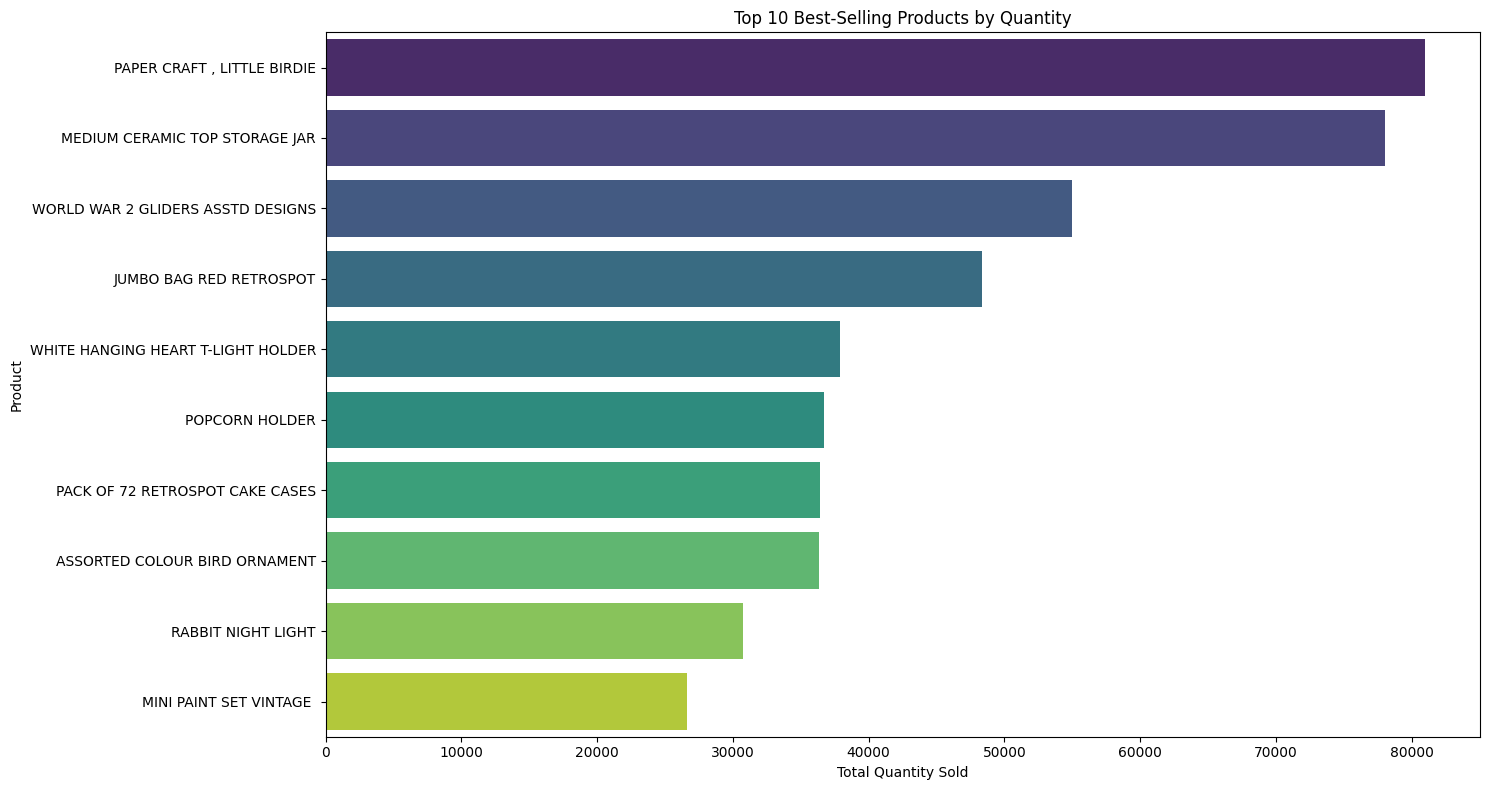

In [8]:
top_products = (
    df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(15, 8))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

The bar chart reveals that "Paper Craft Little Birdie" is the best-selling 
product by quantity, significantly outselling the other top products, partially 
supporting the Pareto hypothesis. The majority of top 10 products appear to be 
home décor and novelty items, suggesting this is the core product 
category for this retailer.

---

### Sales Trends Over Time

* How have sales developed month by month over the years?

Hypothesis: The fourth quarter (October-December) will show the 
highest sales activity due to the Christmas shopping period.

In [9]:
monthly_sales = (
    df.groupby(["Year", "Month"])
    .agg(TotalRevenue=("TotalPrice", "sum"), TotalOrders=("InvoiceNo", "nunique"))
    .reset_index()
)

monthly_sales["YearMonth"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

print(monthly_sales.head())

   Year  Month  TotalRevenue  TotalOrders YearMonth
0  2010     12    821452.730         1559   2010-12
1  2011      1    689811.610         1086   2011-01
2  2011      2    522545.560         1100   2011-02
3  2011      3    716215.260         1454   2011-03
4  2011      4    536968.491         1246   2011-04


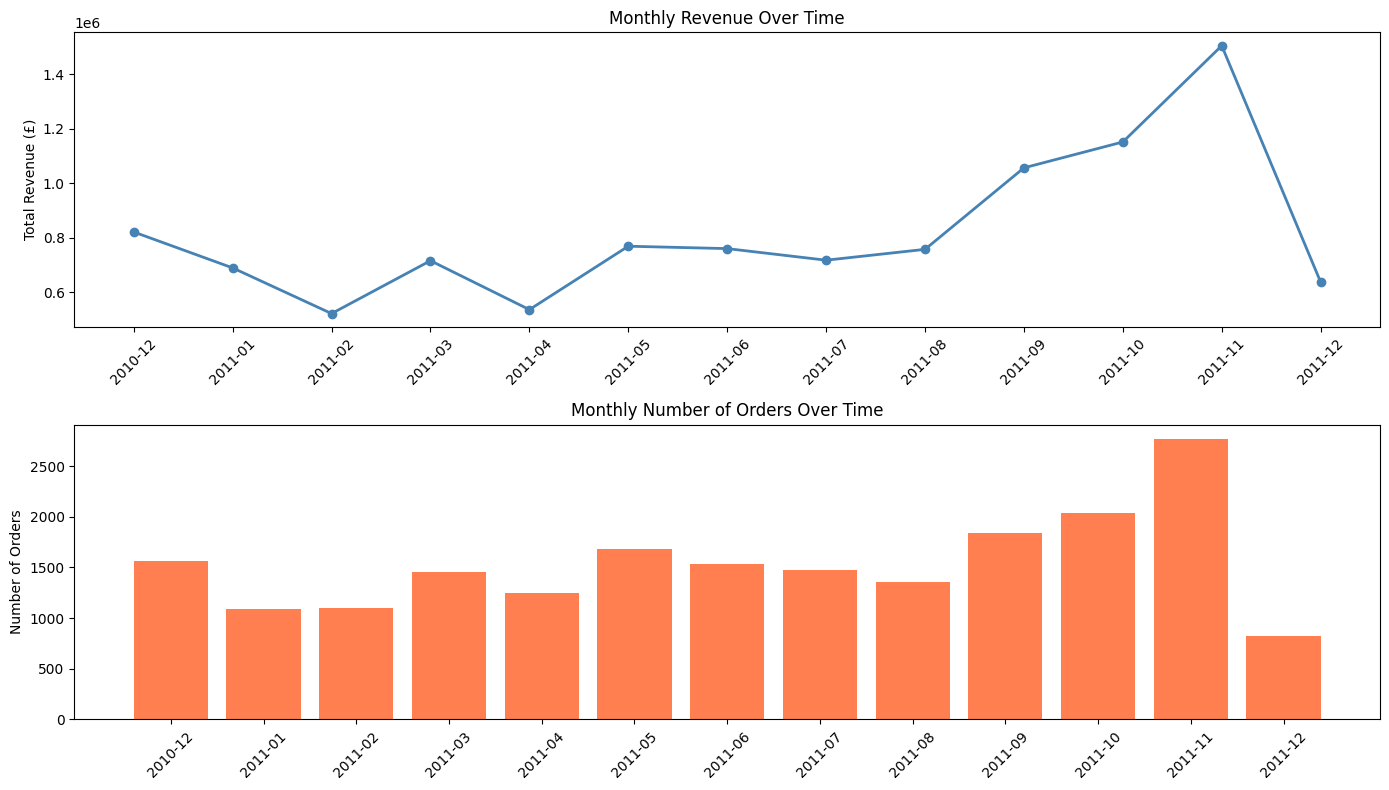

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Line chart - Revenue
axes[0].plot(
    monthly_sales["YearMonth"],
    monthly_sales["TotalRevenue"],
    color="steelblue",
    marker="o",
    linewidth=2,
)
axes[0].set_title("Monthly Revenue Over Time")
axes[0].set_ylabel("Total Revenue (£)")
axes[0].tick_params(axis="x", rotation=45)

# Bar chart - Orders
axes[1].bar(monthly_sales["YearMonth"], monthly_sales["TotalOrders"], color="coral")
axes[1].set_title("Monthly Number of Orders Over Time")
axes[1].set_ylabel("Number of Orders")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The subplot shows a clear upward trend in both revenue and number of orders 
towards the end of 2011, with a peak in November 2011. This supports the 
hypothesis that Q4 sees the highest sales activity due to Christmas shopping. 
December shows a drop which may be due to incomplete data for that month.

---

### Price vs Quantity Relationship

* Is there a correlation between product price and quantity sold? 
Do cheaper products tend to sell in higher quantities?

Hypothesis: Products with a lower unit price will have a higher quantity sold.

In [11]:
price_quantity = (
    df.groupby("Description")
    .agg(AveragePrice=("UnitPrice", "mean"), TotalQuantity=("Quantity", "sum"))
    .reset_index()
)
print(price_quantity.head())

                      Description  AveragePrice  TotalQuantity
0   4 PURPLE FLOCK DINNER CANDLES      2.450513            142
1   50'S CHRISTMAS GIFT BAG LARGE      1.426589           1915
2               DOLLY GIRL BEAKER      1.506420           2451
3     I LOVE LONDON MINI BACKPACK      4.616667            388
4     I LOVE LONDON MINI RUCKSACK      4.150000              1


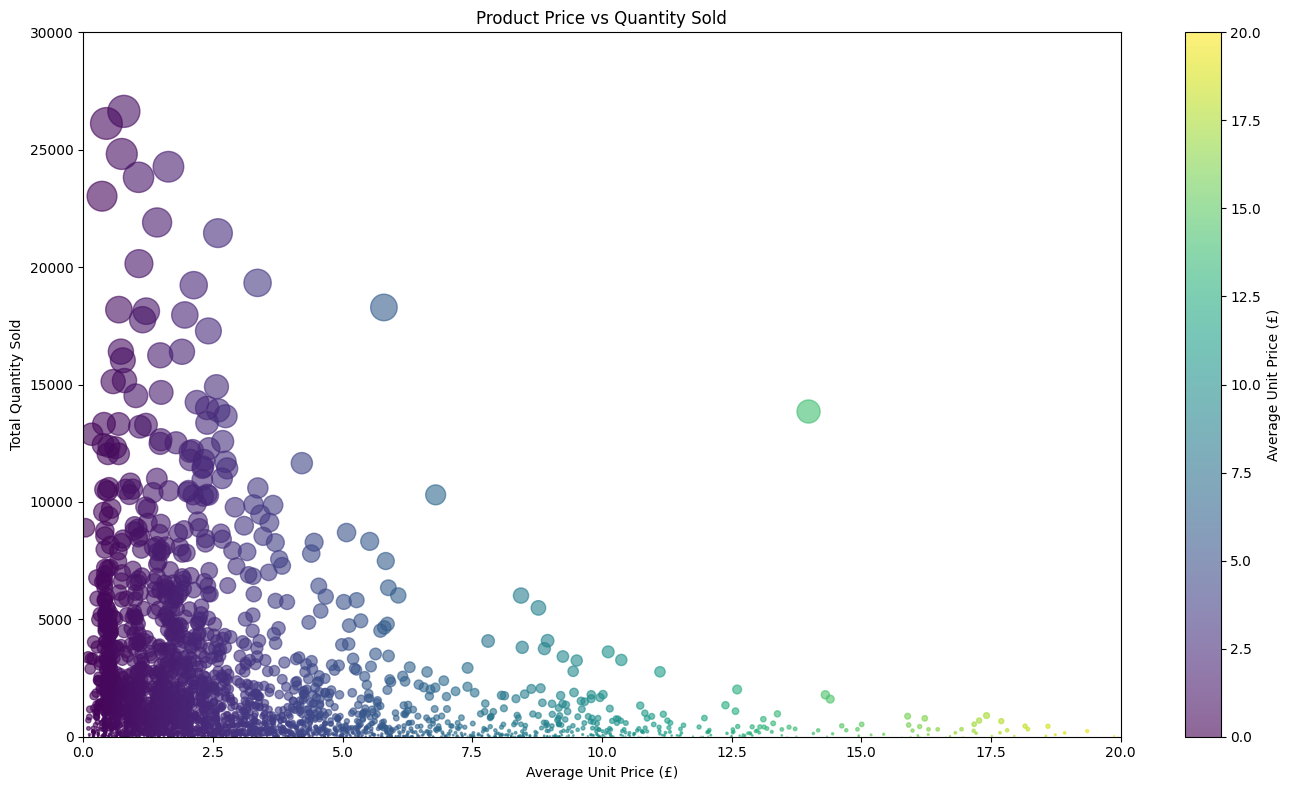

In [13]:
fig, axes = plt.subplots(figsize=(14, 8))
scatter = axes.scatter(
    price_quantity["AveragePrice"],
    price_quantity["TotalQuantity"],
    c=price_quantity["AveragePrice"],
    cmap="viridis",
    alpha=0.6,
    s=price_quantity["TotalQuantity"] / 50,
    vmin=0,
    vmax=20,
)

plt.colorbar(scatter, ax=axes, label="Average Unit Price (£)")
plt.title("Product Price vs Quantity Sold")
plt.xlabel("Average Unit Price (£)")
plt.ylabel("Total Quantity Sold")
plt.xlim(0, 20)
plt.ylim(0, 30000)
plt.tight_layout()
plt.show()

The scatter plot clearly supports the hypothesis. Products with lower unit 
prices (shown in purple) consistently achieve higher sales volumes, with the 
largest bubbles concentrated in the under £5 price range. As price increases, 
both bubble size and quantity sold decrease significantly, confirming a negative 
relationship between price and quantity sold.

---

## AI Integration Note

GitHub Copilot was asked: "How can I make this scatterplot more easy to understand?"

Copilot suggested several improvements including adding a trendline, 
using transparency to reduce overplotting, log scaling for skewed data, 
and an interactive Plotly version with colour scaling and size mapping.

Based on these suggestions, the following improvement was implemented:
- An interactive Plotly scatter plot with colour scale (price) and 
  bubble size (quantity) to better communicate the price-quantity relationship

> **Note:** The interactive Plotly version below requires `nbformat>=4.2.0` 
> to render inline in Jupyter. If it does not display, the plot will 
> automatically be saved as an HTML file and opened in the browser instead.

In [3]:
# Interactive Plotly scatter with fallback that does not require nbformat
import plotly.express as px
import plotly.io as pio
import os, webbrowser

# Use the browser renderer so Plotly doesn't try to render inline (which checks nbformat)
pio.renderers.default = "browser"

fig = px.scatter(
    price_quantity,
    x="AveragePrice",
    y="TotalQuantity",
    size="TotalQuantity",  # or 'TotalRevenue'
    size_max=40,
    color="AveragePrice",
    hover_data={"Description": True, "AveragePrice": ":.2f", "TotalQuantity": True},
    labels={
        "AveragePrice": "Average Price (£)",
        "TotalQuantity": "Total Quantity Sold",
    },
    title="Product Price vs Quantity (interactive)",
)

# optional log axis
# fig.update_xaxes(type='log')
# fig.update_yaxes(type='log')

fig.update_layout(template="plotly_white", legend=dict(title="Avg price"))
# Try to show in browser; if that fails, write an HTML file and open it
try:
    fig.show()
except Exception as e:
    out_path = "data/processed/price_quantity_plot.html"
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.write_html(out_path, include_plotlyjs="cdn")
    webbrowser.open("file://" + os.path.abspath(out_path))
    print("Plot written to", out_path)

NameError: name 'price_quantity' is not defined

___

### Price Distribution and Normalisation

* How is unit price distributed across all products, and can a 
Box-Cox transformation normalise the distribution?

Hypothesis: UnitPrice will be right-skewed (most products are cheap, 
few are very expensive). A Box-Cox transformation will normalise 
the distribution towards a bell curve.

In [14]:
df_price = df[["UnitPrice"]].copy()
df_price = df_price[df_price["UnitPrice"] > 0]

df_price.head()

,UnitPrice
0,2.55
1,3.39
2,2.75
3,3.39
4,3.39


The following analysis uses the BoxCoxTransformer from the feature_engine 
library, as covered in the course material, applied here to the UnitPrice 
column of the online retail dataset.

*** UnitPrice ***


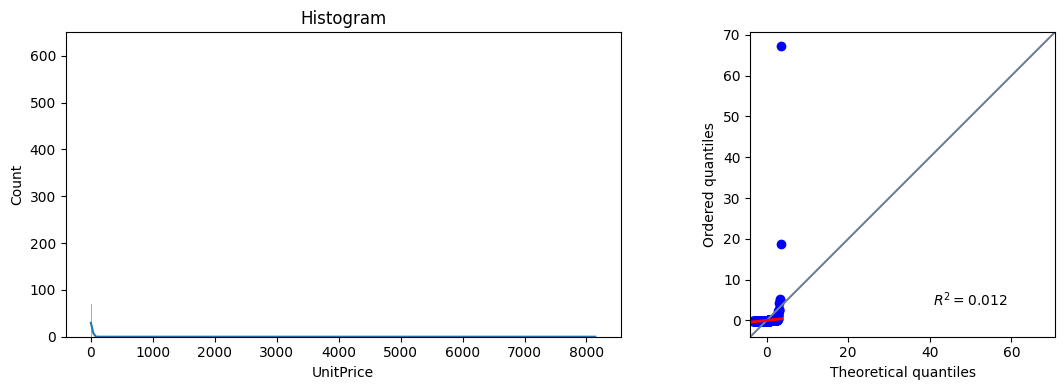

before apply transformation  | skewness: 62.28 | kurtosis: 4119.08




In [15]:
import pingouin as pg


def calculate_skew_kurtosis(df, col, moment):
    print(
        f"{moment}  | skewness: {df[col].skew().round(2)} | kurtosis: {df[col].kurtosis().round(2)}"
    )


def distribution_before_applying_transformer(df):
    for col in df.columns:
        print(f"*** {col} ***")
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
        sns.histplot(data=df, x=col, kde=True, ax=axes[0])
        axes[0].set_title("Histogram")
        pg.qqplot(df[col], dist="norm", ax=axes[1])
        plt.tight_layout()
        plt.show()
        calculate_skew_kurtosis(df, col, "before apply transformation")
        print("\n")


def compare_distributions_before_and_after_applying_transformer(
    df, df_transformed, method
):
    for col in df.columns:
        print(f"*** {col} ***")
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
        sns.histplot(data=df, x=col, kde=True, ax=axes[0, 0])
        axes[0, 0].set_title(f"Before {method}")
        pg.qqplot(df[col], dist="norm", ax=axes[0, 1])

        sns.histplot(data=df_transformed, x=col, kde=True, ax=axes[1, 0])
        axes[1, 0].set_title(f"After {method}")
        pg.qqplot(df_transformed[col], dist="norm", ax=axes[1, 1])

        plt.tight_layout()
        plt.show()
        calculate_skew_kurtosis(df, col, moment="before transformation")
        calculate_skew_kurtosis(df_transformed, col, moment="after transformation")
        print("\n")


df_price_sample = df_price.sample(n=5000, random_state=42)
distribution_before_applying_transformer(df_price_sample)

In [16]:
pipeline = Pipeline([("bct", vt.BoxCoxTransformer())])

df_transformed = pipeline.fit_transform(df_price_sample)
df_transformed.head()

,UnitPrice
404269,0.780143
293030,0.488919
206516,-0.163794
387547,1.325886
445148,0.477290


> **Note — How to read this plot:**
>
> Each analysis shows two charts side by side:
> - **Histogram (left):** Shows the distribution of UnitPrice. A bell-shaped curve indicates a normal distribution.
> - **QQ-plot (right):** Compares the data against a perfect normal distribution. If the points follow the diagonal line closely, the data is normally distributed. R² measures how well the data fits the line — a value close to 1.0 means near-perfect normality.

*** UnitPrice ***


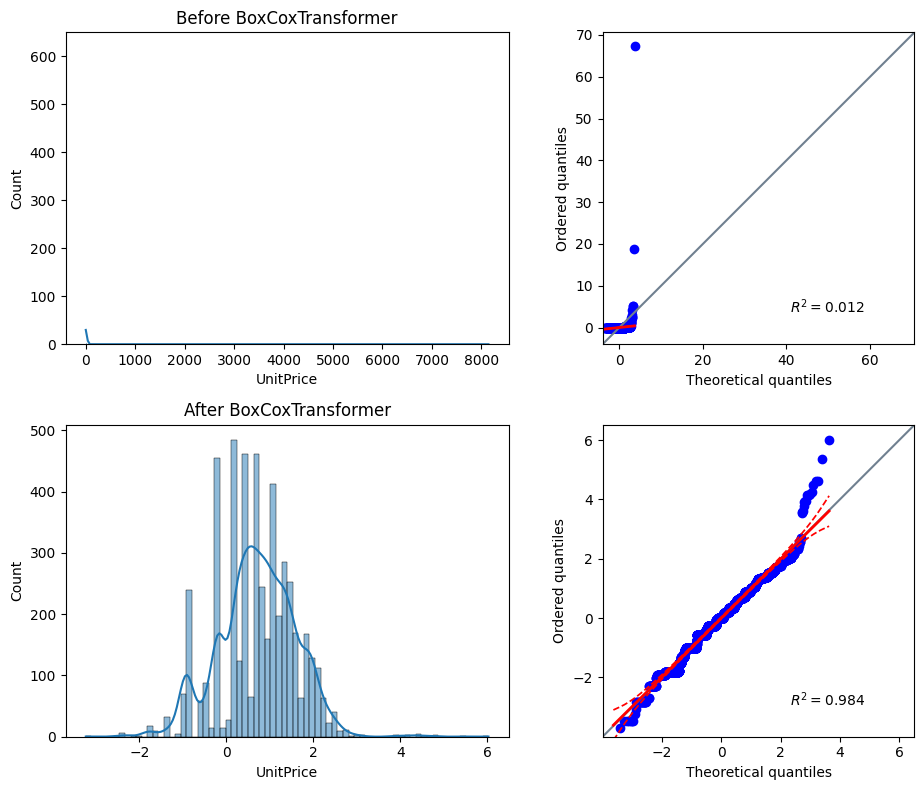

before transformation  | skewness: 62.28 | kurtosis: 4119.08
after transformation  | skewness: -0.04 | kurtosis: 0.96




In [17]:
compare_distributions_before_and_after_applying_transformer(
    df_price_sample, df_transformed, method="BoxCoxTransformer"
)

The Box-Cox transformation successfully normalised the UnitPrice distribution. 
Before transformation, the data was heavily right-skewed (R²=0.012). 
After transformation, the distribution closely follows a normal bell curve 
(R²=0.984), confirming the hypothesis.

___

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
